# ==========================================================
#  RFM Modelling Pipeline
# ==========================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# PDF LIBRARY (MANDATORY TOOL)
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet

plt.rcParams['figure.figsize'] = (8,5)


In [2]:
# ==========================================================
# 📥 LOAD DATA
# ==========================================================
df = pd.read_csv("RFM_data.csv", encoding='latin1')

rfm = df[['Recency','Frequency','Monetary']]

print("Dataset Shape:", df.shape)


Dataset Shape: (18482, 9)


       customer_key       Recency     Frequency      Monetary  Recency_Score  \
count  18482.000000  18482.000000  18482.000000  18482.000000   18482.000000   
mean    9242.344281   4640.335786      1.496429   1588.099665       2.994643   
std     5335.992085    146.296278      1.101186   2123.778423       1.417624   
min        1.000000   4451.000000      1.000000      2.000000       1.000000   
25%     4621.250000   4537.000000      1.000000     50.000000       2.000000   
50%     9242.500000   4619.000000      1.000000    272.000000       3.000000   
75%    13862.750000   4714.000000      2.000000   2511.000000       4.000000   
max    18484.000000   5577.000000     28.000000  13294.000000       5.000000   

       Frequency_Score  Monetary_Score  
count     18482.000000    18482.000000  
mean          1.628558        2.989287  
std           0.483203        1.413446  
min           1.000000        1.000000  
25%           1.000000        2.000000  
50%           2.000000        3.0

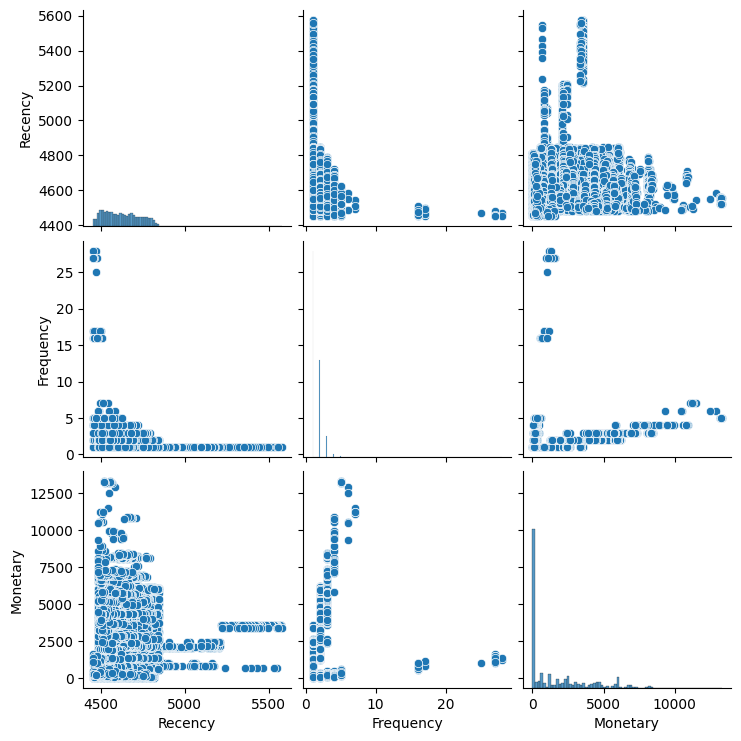

In [3]:
# ==========================================================
# 🔍 EDA
# ==========================================================
print(df.describe())

sns.pairplot(rfm)
plt.show()


In [4]:
# ==========================================================
# ⚙️ SCALING
# ==========================================================
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

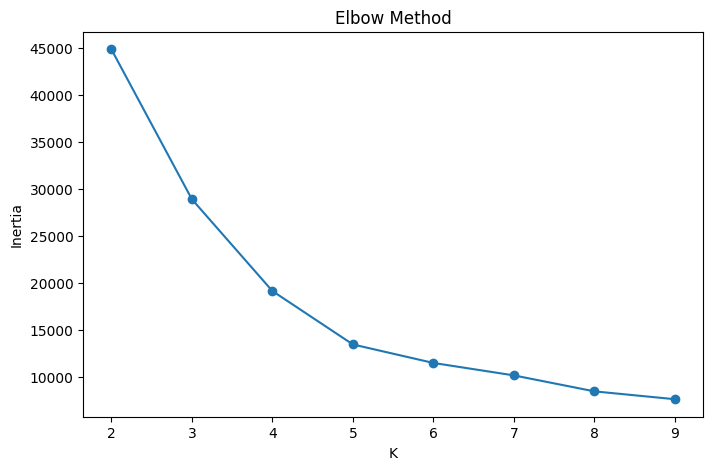

In [5]:
# ==========================================================
# 📉 ELBOW METHOD
# ==========================================================
inertia = []
K_range = range(2, 10)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()



🔍 Running Hyperparameter Tuning (Silhouette Optimization)
   K  Silhouette
0  2    0.894757
1  3    0.514341
2  4    0.511699
3  5    0.422228
4  6    0.403619
5  7    0.402987
6  8    0.424706
7  9    0.423929


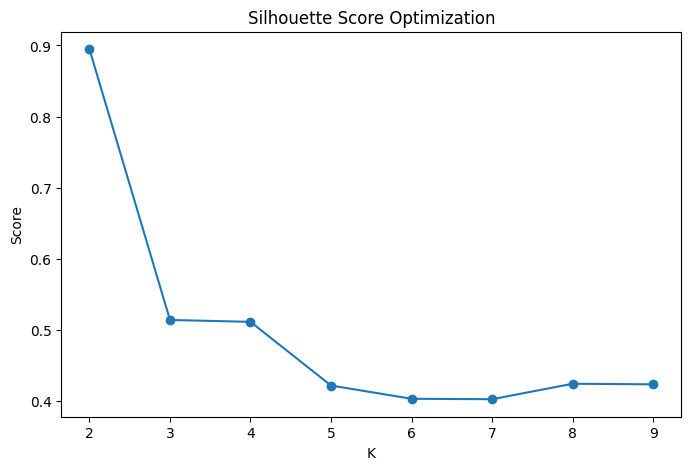

In [6]:
# ==========================================================
# 🔍 HYPERPARAMETER TUNING (GRID SEARCH FOR K)
# ==========================================================
print("\n🔍 Running Hyperparameter Tuning (Silhouette Optimization)")

results = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    
    score = silhouette_score(rfm_scaled, labels)
    
    results.append({
        "K": k,
        "Silhouette": score
    })

results_df = pd.DataFrame(results)

print(results_df)

# Plot silhouette scores
plt.plot(results_df['K'], results_df['Silhouette'], marker='o')
plt.title("Silhouette Score Optimization")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()


In [7]:
# ==========================================================
# 🎯 SELECT BEST K
# ==========================================================
optimal_k = results_df.loc[results_df['Silhouette'].idxmax(), 'K']
print(f"\n✅ Optimal K selected: {optimal_k}")


✅ Optimal K selected: 2


In [8]:
# ==========================================================
# 🚀 FINAL MODEL
# ==========================================================
kmeans = KMeans(n_clusters=int(optimal_k), random_state=42)
df['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [9]:
# ==========================================================
# 📊 CLUSTER SUMMARY
# ==========================================================
cluster_summary = df.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
print(cluster_summary)


             Recency  Frequency     Monetary
Cluster                                     
0        4640.661788   1.460183  1589.241340
1        4468.514286  20.600000   986.371429



📊 SHAP-like Feature Importance
          Recency  Frequency  Monetary
Cluster                               
0        0.349057   0.214361  0.436582
1        0.000666   0.998594  0.000740


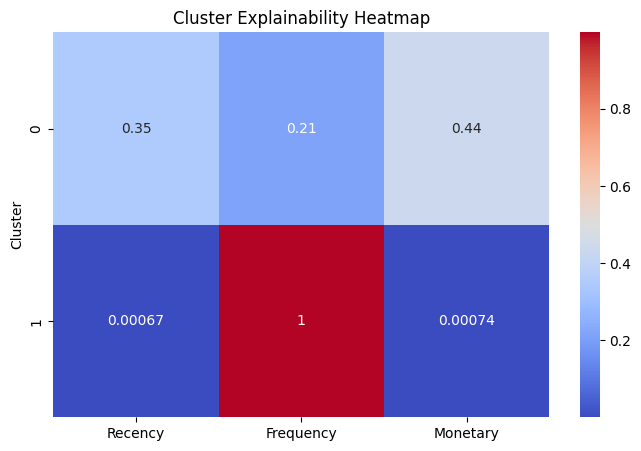

In [10]:
# ==========================================================
# 🧠 SHAP-LIKE EXPLAINABILITY (ADD HERE)
# ==========================================================

def explain_cluster_assignment(data_scaled, model, feature_names):
    explanations = []

    centroids = model.cluster_centers_
    labels = model.predict(data_scaled)

    for i, point in enumerate(data_scaled):
        cluster = labels[i]
        centroid = centroids[cluster]
        
        # Contribution = squared distance per feature
        contribution = (point - centroid) ** 2
        
        # Normalize (convert to % contribution)
        contribution = contribution / np.sum(contribution)
        
        explanation = dict(zip(feature_names, contribution))
        
        explanations.append({
            "Cluster": cluster,
            **explanation
        })
    
    return pd.DataFrame(explanations)


# Apply explainability
feature_names = ['Recency','Frequency','Monetary']

explain_df = explain_cluster_assignment(rfm_scaled, kmeans, feature_names)

# ==========================================================
# 📊 GLOBAL FEATURE IMPORTANCE (LIKE SHAP SUMMARY)
# ==========================================================
importance = explain_df.groupby("Cluster")[feature_names].mean()

print("\n📊 SHAP-like Feature Importance")
print(importance)

# Optional visualization
sns.heatmap(importance, annot=True, cmap='coolwarm')
plt.title("Cluster Explainability Heatmap")
plt.show()

In [11]:
# ==========================================================
# 🧠 AUTO CLUSTER NAMING (RANK-BASED)
# ==========================================================
ranked = cluster_summary.rank()

cluster_labels = {}

for i in ranked.index:
    r = ranked.loc[i,'Recency']
    f = ranked.loc[i,'Frequency']
    m = ranked.loc[i,'Monetary']
    
    if r <= 2 and f >= 3 and m >= 3:
        cluster_labels[i] = "Champions"
    elif r >= 3 and f <= 2:
        cluster_labels[i] = "At Risk"
    elif f >= 3:
        cluster_labels[i] = "Loyal Customers"
    elif m >= 3:
        cluster_labels[i] = "Big Spenders"
    else:
        cluster_labels[i] = "Others"

df['Segment_KMeans'] = df['Cluster'].map(cluster_labels)

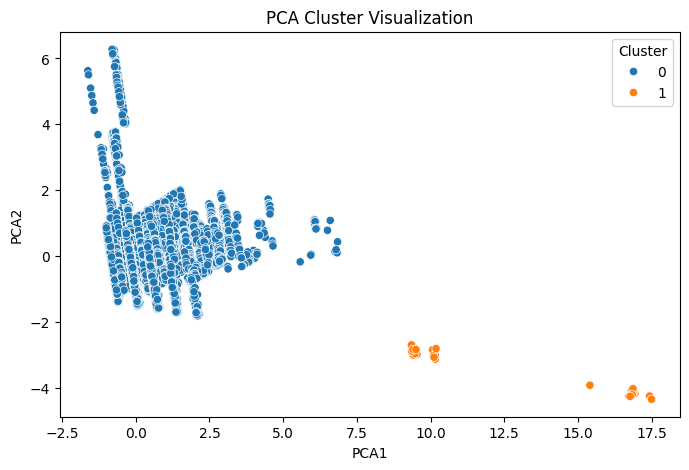

In [12]:
# ==========================================================
# 📉 PCA VISUALIZATION
# ==========================================================
pca = PCA(n_components=2)
pca_data = pca.fit_transform(rfm_scaled)

df['PCA1'] = pca_data[:,0]
df['PCA2'] = pca_data[:,1]

sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster')
plt.title("PCA Cluster Visualization")
plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_19884\3178796430.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  values = np.append(values, values[0])


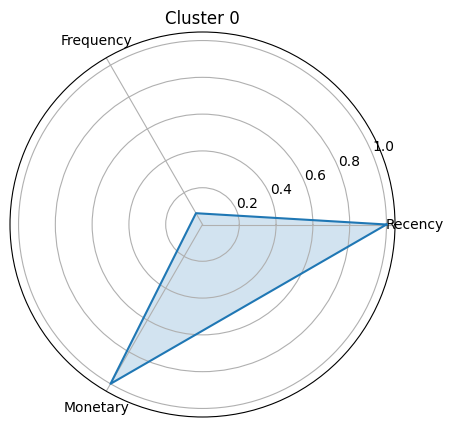

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_19884\3178796430.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  values = np.append(values, values[0])


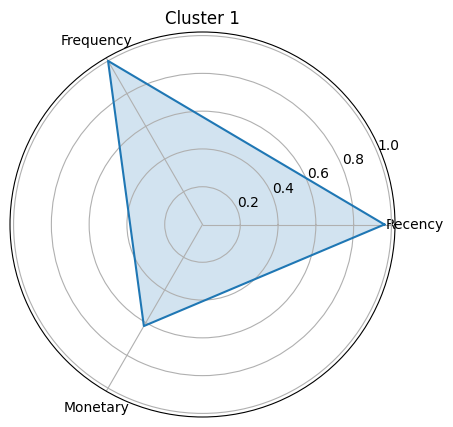

In [13]:
# ==========================================================
# 🧭 RADAR CHARTS
# ==========================================================
features = ['Recency','Frequency','Monetary']

for cluster in cluster_summary.index:
    values = cluster_summary.loc[cluster].values
    values = values / cluster_summary.max()
    
    values = np.append(values, values[0])
    angles = np.linspace(0, 2*np.pi, len(features), endpoint=False)
    angles = np.append(angles, angles[0])
    
    fig, ax = plt.subplots(subplot_kw={'polar': True})
    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features)
    ax.set_title(f"Cluster {cluster}")
    
    plt.show()


In [14]:
# ==========================================================
# 📏 FINAL EVALUATION
# ==========================================================
final_score = silhouette_score(rfm_scaled, df['Cluster'])
print(f"\nFinal Silhouette Score: {final_score:.3f}")



Final Silhouette Score: 0.895


In [15]:
# ================================
# 💾 SAVE ARTIFACTS
# ================================

pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(kmeans, open("kmeans.pkl", "wb"))
pickle.dump(cluster_labels, open("cluster_labels.pkl", "wb"))

df.to_csv("rfm_clustered_output.csv", index=False)

# 🔥 SAVE EXPLAINABILITY (IMPORTANT)
explain_df.to_csv("cluster_explainability.csv", index=False)

In [16]:
# ==========================================================
# 📄 AUTOMATED PDF REPORT GENERATION
# ==========================================================
print("\n📄 Generating PDF Report...")

doc = SimpleDocTemplate("RFM_Clustering_Report.pdf")
styles = getSampleStyleSheet()

content = []

# Title
content.append(Paragraph("Customer Segmentation Report", styles['Title']))
content.append(Spacer(1, 12))

# Dataset Info
content.append(Paragraph(f"Total Customers: {len(df)}", styles['Normal']))
content.append(Paragraph(f"Optimal Clusters (K): {optimal_k}", styles['Normal']))
content.append(Paragraph(f"Silhouette Score: {round(final_score,3)}", styles['Normal']))
content.append(Spacer(1, 12))

# Cluster Summary
content.append(Paragraph("Cluster Summary:", styles['Heading2']))

for i in cluster_summary.index:
    row = cluster_summary.loc[i]
    label = cluster_labels[i]
    
    text = f"""
    Cluster {i} ({label})<br/>
    Recency: {round(row['Recency'],2)}<br/>
    Frequency: {round(row['Frequency'],2)}<br/>
    Monetary: {round(row['Monetary'],2)}<br/><br/>
    """
    
    content.append(Paragraph(text, styles['Normal']))
    content.append(Spacer(1, 10))

doc.build(content)

print("✅ PDF Report Generated Successfully")


📄 Generating PDF Report...
✅ PDF Report Generated Successfully
